In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('/content/Live.csv')

In [ ]:
df=df.dropna(axis=1)

In [ ]:
df[df.duplicated(keep=False)].sort_values(by='status_id')

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         7050 non-null   object
 1   status_type       7050 non-null   object
 2   status_published  7050 non-null   object
 3   num_reactions     7050 non-null   int64 
 4   num_comments      7050 non-null   int64 
 5   num_shares        7050 non-null   int64 
 6   num_likes         7050 non-null   int64 
 7   num_loves         7050 non-null   int64 
 8   num_wows          7050 non-null   int64 
 9   num_hahas         7050 non-null   int64 
 10  num_sads          7050 non-null   int64 
 11  num_angrys        7050 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 661.1+ KB


In [ ]:
df['status_published'] = pd.to_datetime(df['status_published'])

In [ ]:
df['hour']=df['status_published'].dt.hour

In [ ]:
df['day_name']=df['status_published'].dt.day_name()

In [ ]:
df['month']=df['status_published'].dt.month_name()

In [ ]:
df['week_type']=np.where(df['status_published'].dt.weekday<5, 'Weekday','Weekend')

In [ ]:
df

In [ ]:
df1=df.drop(columns=['status_id', 'status_published'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()
cols_to_encode=['status_type', 'week_type', 'day_name' , 'month']
for col in cols_to_encode:
 df1[col]= encoder.fit_transform(df1[col])

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_scaled=scaler.fit_transform(df1)

In [ ]:
from sklearn.cluster import KMeans
kmeans= KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [ ]:
df1['Clusters']=kmeans.labels_

In [ ]:
df1

In [ ]:
df1['Clusters'].value_counts()

,count
Clusters,
1,4346
0,2093
2,365
3,195


In [ ]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

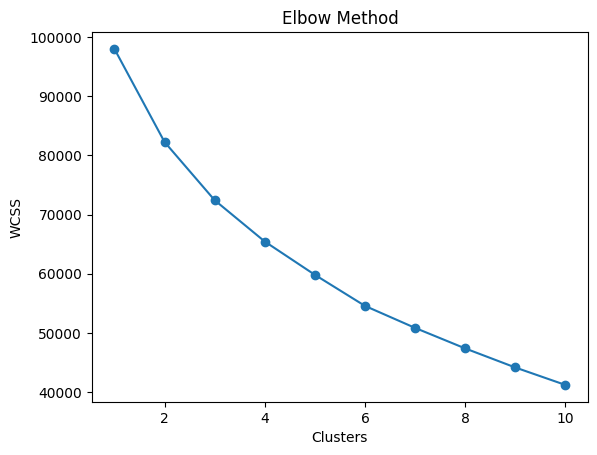

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    df1['Clusters']
)

print(score)

0.2140428220113529


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

/tmp/ipykernel_837/2953888608.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


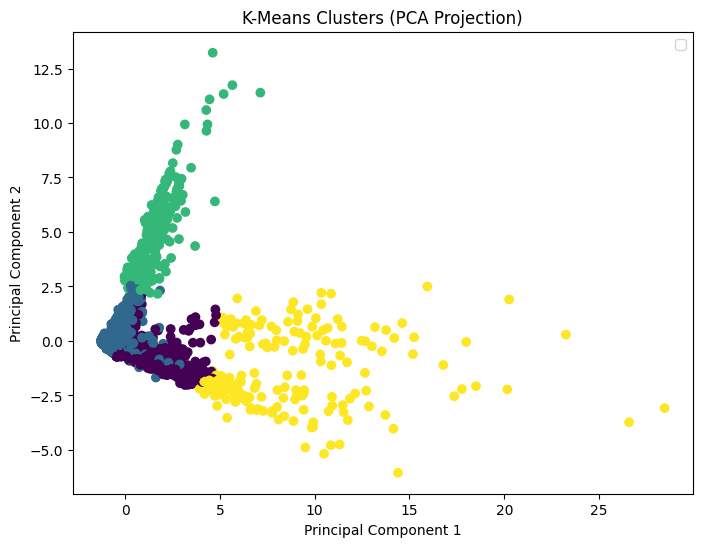

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df1['Clusters'],
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA Projection)")
plt.legend(loc='upper right')

plt.show()